# Clustering intro #14

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist

### New tool: k-means clustering

enter k-means clustering - a popular unsupervised algorithm. specifically, it's for centroid-based clustering, which focuses on finding good representatives.

### Simple dataset in 2D
let's generate 3 radnom blobs of points

In [2]:
def generate_blobs(k, n, width, d=2):  # k clusters, each with n points, in d-dimensional space

    # this creates artificial data that k-means will try to rediscovver 
    # by minimizing the squared-distance objective above
    # width controls how spread out each cluster is

    
    '''
    just generates k blobs, each of size n
    '''
    C = np.random.random((1, k, d))
    X = C + np.random.randn(n, k, d)*width
    return X.reshape((k*n), d)

#### why it works:
the algorithm performs coordinate descent on the objective functino:
* fix centroids -> optimize assignments
* fix assignments -> optimize centroids

each step minimizes the objective given the order

(np.float64(0.711869042269144),
 np.float64(1.0819013945935658),
 np.float64(0.11129960100115825),
 np.float64(1.1119964601663646))

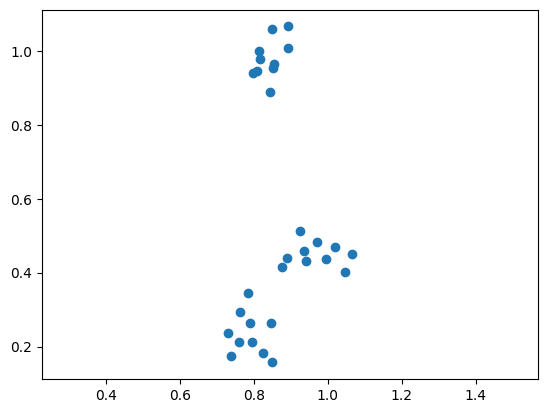

In [3]:
np.random.seed(13)
X = generate_blobs(3, 10, 0.05) 
# 3 clusters, 10 points each clusters, 0.05 width, default dimension(2)
# so, drop 3 centers, around each cente,r sprinkle 10 points
# sprinkle them very close to the center (width = 0.05)
# d=2 > do this on a flat sheet of paper
plt.scatter(X.T[0], X.T[1])
plt.axis('equal')

### Task 1

What 3 points on the plane would represent these three blobs well?

(np.float64(0.711869042269144),
 np.float64(1.0819013945935658),
 np.float64(0.11129960100115825),
 np.float64(1.1119964601663646))

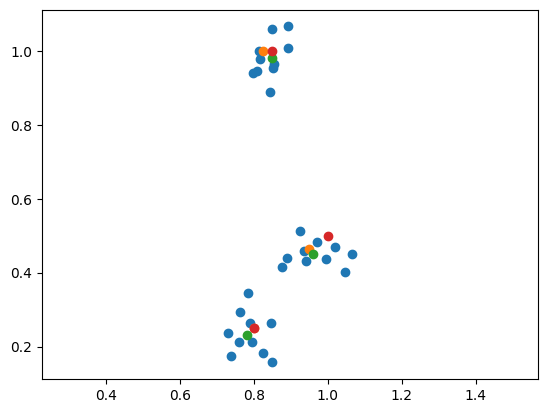

In [4]:
# fill in your best guess for representatives of the 3 clusters below
C1 = np.array([(0.8, 0.25), (0.95, 0.465), (.825, 1.0)]) # Orange Point

# We'll use this in a moment
C2 = np.array([(0.78, 0.23), (0.96, 0.45), (0.85, 0.98)]) # Green Point
C3 = np.array([(0.8, 0.25), (1.0, 0.5), (0.85, 1.0)]) # Red Point

plt.scatter(X.T[0], X.T[1])

for C in [C1, C2, C3]:
    plt.scatter(C.T[0], C.T[1])

plt.axis('equal')

* cluster_centers_: array of k cluster centers (aka centroids)
* labels_: array of labels for each point in X. the label is just the index of the nearest cluter center

In [5]:
from sklearn.cluster import KMeans

In [12]:
km = KMeans(n_clusters=3) # initialize the model

# create a k-means model that will try to find 3 clusters

In [13]:
km.fit(X); # fit the data

# this is the algorithm
# step1 - guess centers randomly 
# step2 - assign points to nearest center
# step3 - recompute centers
# for each cluster : new center = mean of its points
# ex. cluster 0 center = average of all points assigned to cluster 0
# step 4 - repeat

In [15]:
cs = km.cluster_centers_ # get the array of k cluster centers

# this stores the centers o the clusters

print(cs)

[[0.9661273  0.44957393]
 [0.84195262 0.98116708]
 [0.78735477 0.23417525]]


In [17]:
cs.shape

# it prints the shape of the centers matrix
# for 3 clusters in 2D.
# 3 centers, 2 coordinates

(3, 2)

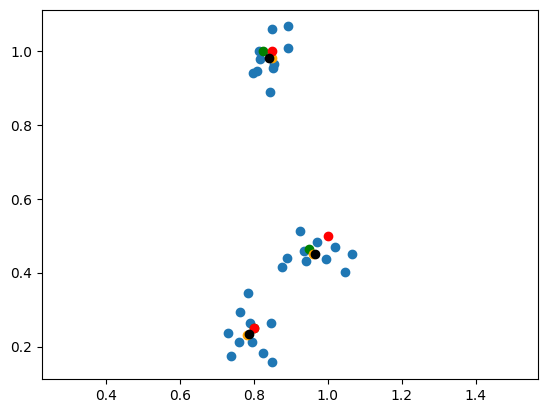

In [18]:
# compare the results with your best bet above
plt.scatter(X.T[0], X.T[1])

plt.scatter(C1.T[0], C1.T[1], c = 'green')
plt.scatter(C2.T[0], C2.T[1], c = 'orange')
plt.scatter(C3.T[0], C3.T[1], c = 'red')
plt.scatter(cs.T[0], cs.T[1], c = 'black')

plt.axis('equal');

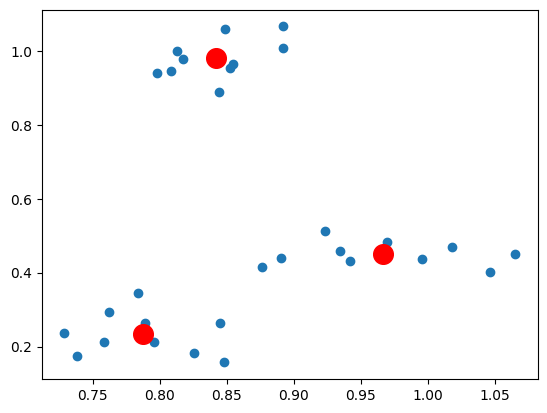

In [20]:
plt.scatter(X[:,0], X[:,1])
plt.scatter(cs[:,0], cs[:,1], color='red', s=200)

# blue points = data
# red points = centroids

### What if we chose a different number of clusters?


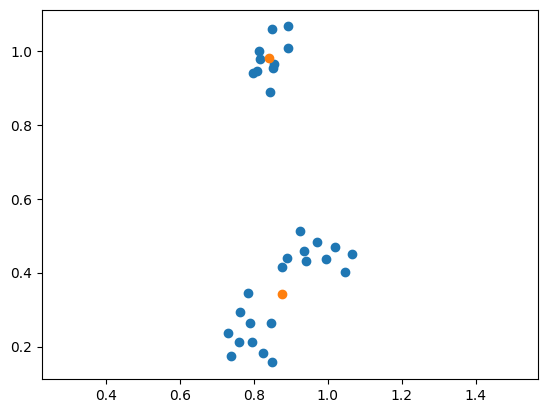

In [23]:
km2 = KMeans(n_clusters=2, n_init='auto')
km2.fit(X)
cs2 = km2.cluster_centers_
plt.scatter(X.T[0], X.T[1])
plt.scatter(cs2.T[0], cs2.T[1])

plt.axis('equal');

### running with 4 clusters

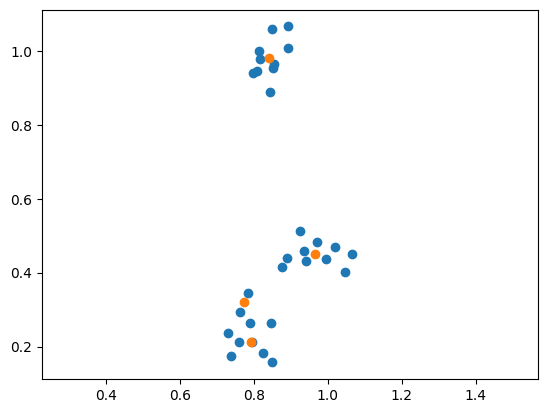

In [24]:
km4 = KMeans(n_clusters=4, n_init='auto')
km4.fit(X)
cs4 = km4.cluster_centers_

plt.scatter(X.T[0], X.T[1])
plt.scatter(cs4.T[0], cs4.T[1])

plt.axis('equal');

### Important task 1: clustering images
now apply k-means to the mnist dataset

some questinos to consider and discuss:
* each cluster center (aka centroid) is a vector -- of what dimension? 2?3? something else?
* can we somehow plot each centroid, or otherwise visualize it

In [36]:
from keras.datasets import mnist, fashion_mnist
(x_train, _), (_) = fashion_mnist.load_data() # we dont care about the labels or test data

x_train = x_train/255 # normalize as usual

# _ means "ignore this (labels)" you're clustering without labels

In [38]:
x_train.shape # currently, (60_000, 28, 28)

(60000, 28, 28)

In [27]:
# initialize kmeans
# specify n_init to remove a warning -- and to make sure it'll run
# the same way in, say, a year
km = KMeans(n_clusters=18)

In [39]:
# fit kmeans with our data (remember to reshape)
km.fit(x_train.reshape(60_000, 28*28))

# reshape to (60_000, 784)

,n_clusters,18
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [40]:
# assign the cluster centers to a varaible centers_as_images
centers = km.cluster_centers_

# this is an array of k centroids

In [31]:
centers.shape

(18, 784)

In [41]:
centers_as_images = centers.reshape(-1, 28, 28)

# -1 means "infer this number automatically"

In [34]:
centers_as_images.shape

(18, 28, 28)

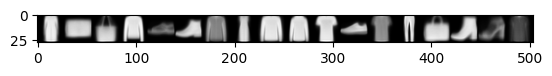

In [44]:
plt.imshow(np.concatenate(centers_as_images, axis =1), cmap='gray')

# axis = 1 horizontal 
# gray -> grayscale picture

# > this is exactly "show me the 18 averages images next to each other"

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

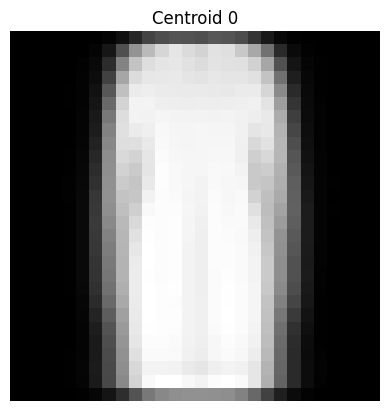

In [51]:
plt.imshow(centers_as_images[0], cmap="gray")
plt.title("Centroid 0")
plt.axis("off")

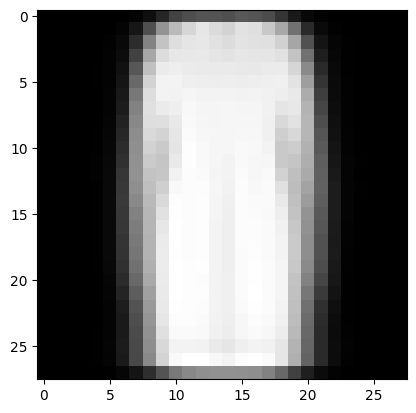

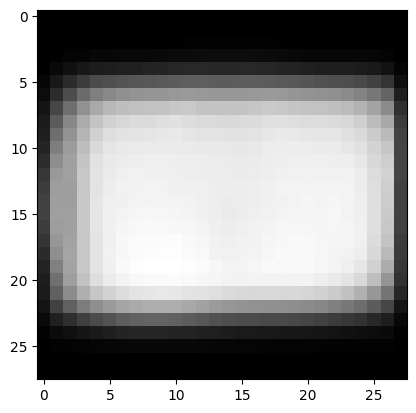

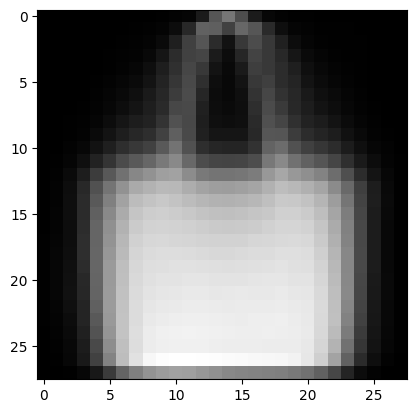

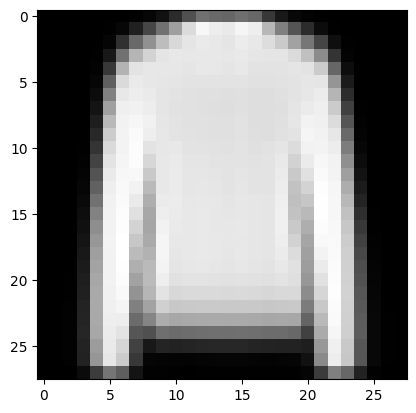

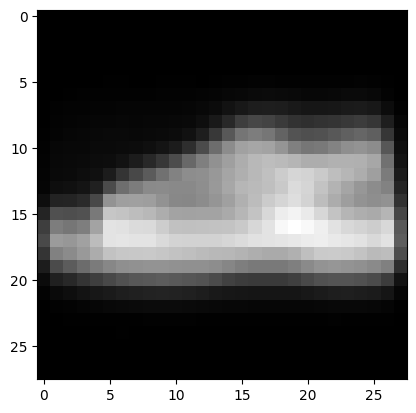

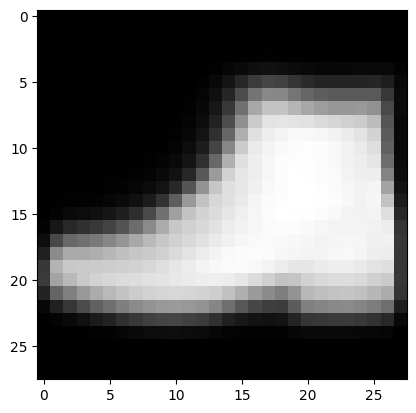

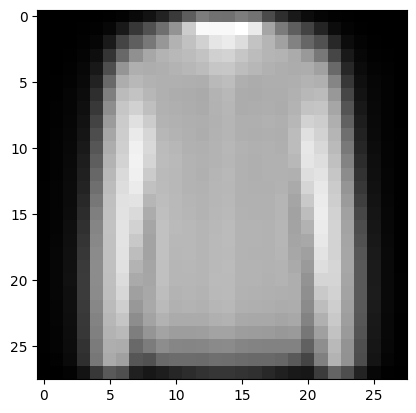

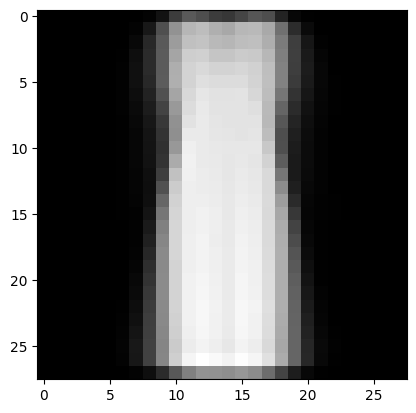

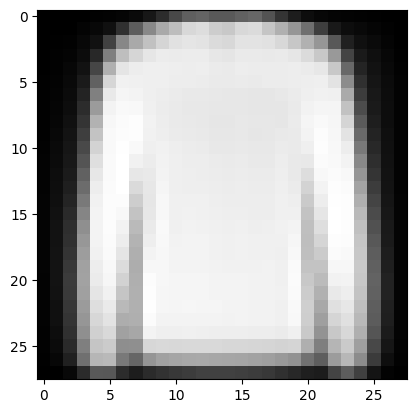

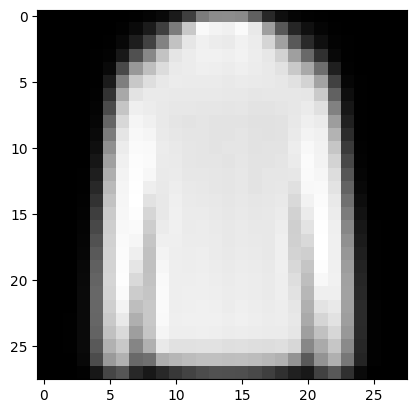

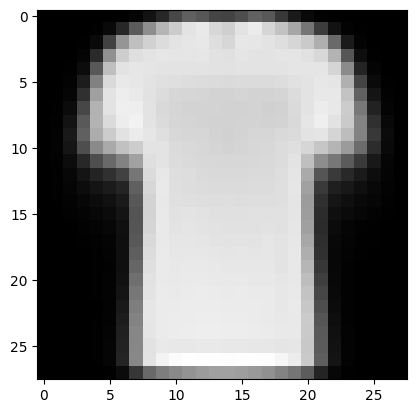

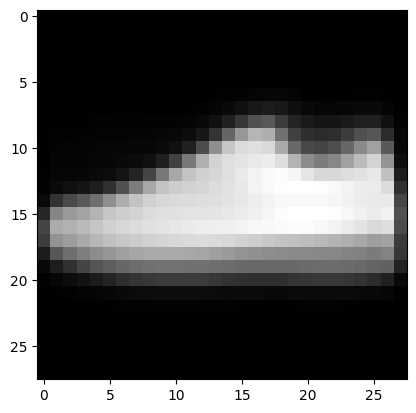

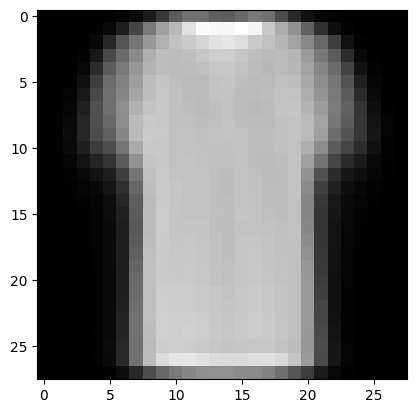

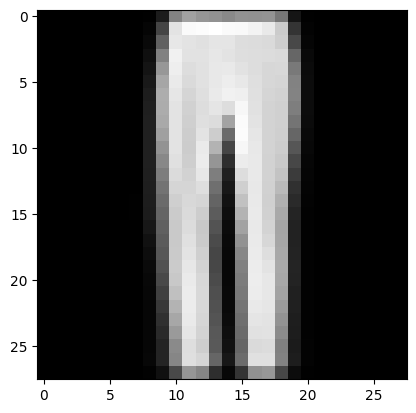

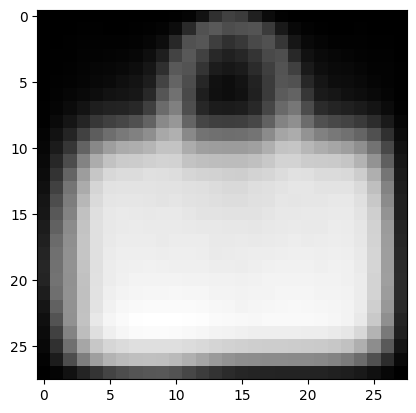

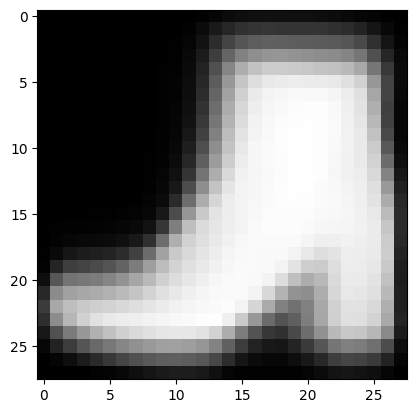

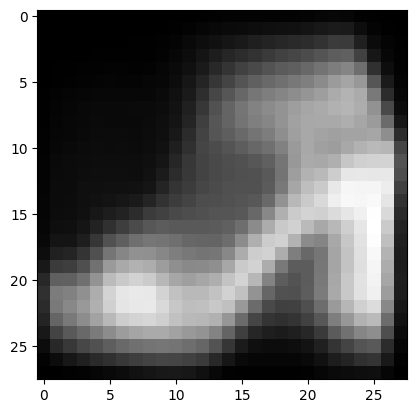

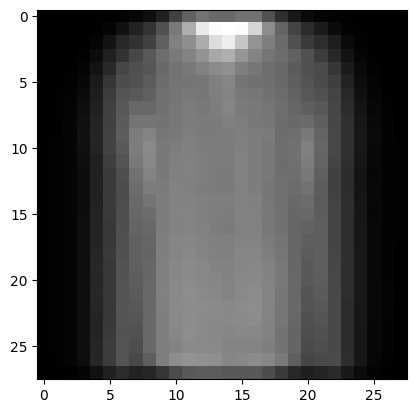

In [47]:
# we can now use this variable visualize all the cluster centers:
for im in centers_as_images:
    plt.imshow(im, cmap='gray')
    plt.show()

### Small Task 2

Repeat the above but for a selected digis, e.g. 7. Try to see how many distinct ways of writing this number there may be. Play with different number of clusters.

(6000, 28, 28)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

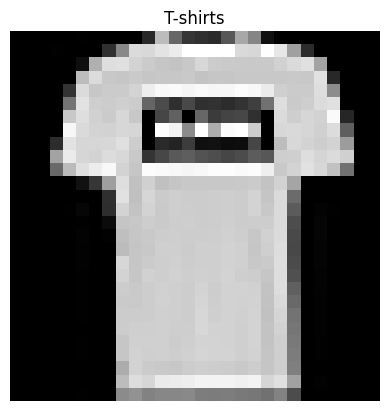

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist
from sklearn.cluster import KMeans

# load fashin mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() 

# normalize to [0,1]
x_train = x_train / 255

# filter to t-shirts
fashion = 0
xtshirts = x_train[y_train==fashion] 

print(xtshirts.shape)

plt.imshow(xtshirts[0], cmap="gray")
plt.title("T-shirts")
plt.axis("off")